# Assignment 05
## Feature Engineering, Data Preparation & Regression Modeling

**Dataset:** student_dataset_dirty.csv

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, accuracy_score, 
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay, classification_report
)

pd.set_option('display.max_columns', None)
%matplotlib inline

# Part A: Data Cleaning & Preparation

In this section, the dataset is loaded and explored to understand its structure. Then, duplicate records, invalid values, missing values, and inconsistent data types are identified and cleaned. The goal is to prepare a clean dataset before applying feature engineering and machine learning models.

## Step 1: Load the Dataset

The dataset is loaded using Pandas. We then examine its shape, data types, summary statistics, and the first few rows to understand the structure of the data.

In [130]:
df = pd.read_csv("student_dataset_dirty.csv")
print(df.shape)
df.head()
df_copy = df.copy()

(10000, 15)


In [131]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  str    
 1   Name                   9958 non-null   str    
 2   Age                    9804 non-null   str    
 3   Gender                 9162 non-null   str    
 4   City                   9775 non-null   str    
 5   Class                  10000 non-null  str    
 6   Attendance_Percentage  9745 non-null   float64
 7   Study_Hours_per_day    9803 non-null   float64
 8   Math_Score             9805 non-null   str    
 9   Science_Score          9800 non-null   str    
 10  English_Score          9804 non-null   str    
 11  Total_Score            9684 non-null   str    
 12  Parent_Education       8900 non-null   str    
 13  Internet_Access        8354 non-null   str    
 14  Result                 8906 non-null   str    
dtypes: float64(2),

,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result
count,10000,9958,9804,9162,9775,10000,9745.000000,9803.000000,9805,9800,9804,9684,8900,8354,8906
unique,9850,385,96,11,28,16,NaN,NaN,195,193,194,380,16,10,8
top,1523,Kabir Ahmed,17,male,rangpur,9,NaN,NaN,81,59,96,203.0,Higher Secondary,N,Fail
freq,2,53,1253,865,636,748,NaN,NaN,159,170,158,111,595,875,1187
mean,NaN,NaN,NaN,NaN,NaN,NaN,84.708897,3.200857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,18.511125,2.800264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,-49.400000,-5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,78.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,84.800000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,91.800000,4.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 2: Check Missing Values and Duplicate Records

The dataset is checked for missing values in each column and duplicate rows. Missing values indicate incomplete data, while duplicate records may negatively affect model performance if not removed.

In [132]:
# missing values per column
df.isnull().sum()

Student_ID                  0
Name                       42
Age                       196
Gender                    838
City                      225
Class                       0
Attendance_Percentage     255
Study_Hours_per_day       197
Math_Score                195
Science_Score             200
English_Score             196
Total_Score               316
Parent_Education         1100
Internet_Access          1646
Result                   1094
dtype: int64

In [133]:
# Duplicate rows
print("Duplicate rows:", df_copy.duplicated().sum())

df_copy = df_copy.drop_duplicates().reset_index(drop = True)
print("Shape after dropping duplicates: ", df_copy.shape)

Duplicate rows: 150


Shape after dropping duplicates:  (9850, 15)


## Step 3: Data Type Conversion and Invalid Value Handling

Some columns that should contain numeric values were initially stored as text (`object` type). These columns were converted to numeric format using `pd.to_numeric()`, where invalid text values were automatically converted into missing values (`NaN`).

After converting the data types, logical validation rules were applied to identify invalid or unrealistic values. For example, age was restricted to a reasonable student age range, attendance was limited between 0 and 100 percent, study hours were limited to 0–16 hours per day, subject scores were restricted to 0–100, and the total score was limited to 0–300. Any values outside these valid ranges were treated as invalid and replaced with `NaN` so they could be handled properly during the missing value imputation step.

## Standardize Categorical Labels

Before encoding the categorical variables, inconsistent category names were standardized to ensure data consistency.

Several columns contained multiple representations of the same category due to differences in capitalization, abbreviations, spelling mistakes, and extra spaces. For example:

- Gender: `Male`, `MALE`, `male`, `M` → `male`
- City: `Dhaka`, `DHAKA`, `Dacca`, ` Dhaka ` → `dhaka`
- Class: `10`, `10th`, `Ten` → `10`
- Parent_Education: `Graduate`, `graduate`, `GRADUATE` → `graduate`
- Internet_Access: `Yes`, `YES`, `Y`, `1` → `yes`
- Result: `P`, `Pass` → `pass`; `F`, `Fail` → `fail`

This standardization prevents duplicate categories from being treated as different values during encoding, reduces unnecessary dummy variables, and improves the quality of the machine learning model.

In [134]:
# Standardize Gender
df_copy['Gender'] = (
    df_copy['Gender']
    .str.strip()
    .str.lower()
)

df_copy['Gender'] = df_copy['Gender'].replace({
    'm':'male',
    'male':'male',
    'f':'female',
    'female':'female',
    'o':'other',
    'other':'other'
})

In [135]:
df_copy['Gender'].value_counts()

Gender
male      3359
female    3245
other     2424
Name: count, dtype: int64

In [136]:
# Standardize City Names

df_copy['City'] = (
    df_copy['City']
    .str.strip()
    .str.lower()
)

df_copy['City'] = df_copy['City'].replace({

    # Dhaka
    'dhaka': 'dhaka',
    'dacca': 'dhaka',

    # Chattogram
    'ctg': 'chattogram',
    'chittagong': 'chattogram',
    'chattogram': 'chattogram',

    # Barishal
    'barisal': 'barishal',
    'barishal': 'barishal',

    # Khulna
    'khulna': 'khulna',

    # Rajshahi
    'rajshahi': 'rajshahi',

    # Rangpur
    'rangpur': 'rangpur',

    # Sylhet
    'sylhet': 'sylhet',

    # Mymensingh
    'mymensign': 'mymensingh',
    'mymensingh': 'mymensingh'
})

In [137]:
df_copy['City'].value_counts()

City
mymensingh    1280
chattogram    1226
rangpur       1220
rajshahi      1195
sylhet        1186
khulna        1185
dhaka         1178
barishal      1161
Name: count, dtype: int64

In [138]:
df_copy['Internet_Access'] = (
    df_copy['Internet_Access'].str.strip().str.lower()
)

df_copy['Internet_Access'] = df_copy['Internet_Access'].replace({
    'y': 'yes',
    'n' : 'no',
    '0' : 'no',
    '1' : 'yes'
})

In [139]:
df_copy['Internet_Access'].value_counts()

Internet_Access
yes    4121
no     4109
Name: count, dtype: int64

In [140]:
# Standardize Class

df_copy['Class'] = (
    df_copy['Class']
    .astype(str)
    .str.strip()
    .str.lower()
)

df_copy['Class'] = df_copy['Class'].replace({

    '6': '6',
    '06': '6',
    '6th': '6',
    'six': '6',

    '7': '7',
    '7th': '7',
    'seven': '7',

    '8': '8',
    '8th': '8',
    'eight': '8',

    '9': '9',
    '9th': '9',
    'nine': '9',

    '10': '10',
    '10th': '10',
    'ten': '10'

})


In [141]:
df_copy['Class'].value_counts()

Class
9     2076
8     1974
7     1948
10    1932
6     1920
Name: count, dtype: int64

In [142]:
df_copy['Result'] = (
    df_copy['Result'].str.strip().str.lower()
)

df_copy['Result'] = df_copy['Result'].replace({
    'f' : 'fail',
    'p' : 'pass'
})

In [143]:
df_copy['Result'].value_counts()

Result
fail    4443
pass    4326
Name: count, dtype: int64

In [144]:
# Standardize Parent Education

df_copy['Parent_Education'] = (
    df_copy['Parent_Education']
    .astype(str)
    .str.strip()
    .str.lower()
)

df_copy['Parent_Education'] = df_copy['Parent_Education'].replace({
    'illiterate': 'illiterate',

    'primary': 'primary',

    'secondary': 'secondary',

    'higher secondary': 'higher secondary',

    'graduate': 'graduate',

    'post graduate': 'postgraduate',
    'postgraduate': 'postgraduate',

    'unknown': 'unknown'

})


In [145]:
df_copy['Parent_Education'].value_counts()

Parent_Education
primary             1651
graduate            1627
unknown             1132
secondary           1127
higher secondary    1110
illiterate          1078
postgraduate        1048
Name: count, dtype: int64

In [146]:
df_copy.sample(10)

,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result
9666,367,Tanvir Sarker,14,male,dhaka,6,76.4,4.7,30,92,50,172.0,primary,no,pass
5246,4878,Fatema Hossain,15,other,chattogram,6,85.6,1.6,54,96,55,205.0,graduate,yes,fail
6478,1211,Hasan Islam,-1,male,khulna,6,82.8,NaN,52,74,91,217.0,postgraduate,yes,pass
3497,8749,Mim Hossain,13,other,sylhet,10,89.3,2.5,84,45,96,225.0,unknown,NaN,pass
9533,STU-02708,Imran Ahmed,12,female,khulna,6,NaN,3.6,83,34,65,185.0,primary,no,fail
1461,1067,Tamim Khan,11,other,chattogram,9,93.7,1.2,59,82,92,233.0,graduate,no,fail
7333,8500,Sabbir Talukder,18,NaN,dhaka,7,75.0,1.9,85,38,34,157.0,graduate,no,pass
1897,2122,Tamim Hossain,12,female,khulna,9,81.0,3.5,70,41,40,151.0,graduate,no,pass
5114,6859,Hasan Ahmed,fifteen,male,khulna,7,98.2,1.8,93,93,44,230.0,primary,yes,fail
9272,7641,Jannat Akter,12,other,sylhet,7,90.3,3.6,58,-32,-39,-13.0,higher secondary,yes,fail


In [147]:

# Handle Invalid Values / Outliers

# Age (Student age should be between 5 and 25)
# print(df_copy['Age'].dtype)
# Age column is string, we need to convert it to numeric
df_copy['Age'] = pd.to_numeric(
    df_copy['Age'],
    errors='coerce'
)
# print(df_copy['Age'].dtype)
df_copy.loc[(df_copy['Age'] < 5) | (df_copy['Age'] > 25), 'Age'] = np.nan

# Attendance Percentage (0 - 100)
# print(df_copy['Attendance_Percentage'].dtype)
df_copy.loc[
    (df_copy['Attendance_Percentage'] < 0) |
    (df_copy['Attendance_Percentage'] > 100),
    'Attendance_Percentage'
] = np.nan

# # Study Hours Per Day (0 - 16 hours)
df_copy.loc[
    (df_copy['Study_Hours_per_day'] < 0) |
    (df_copy['Study_Hours_per_day'] > 16),
    'Study_Hours_per_day'
] = np.nan

df_copy['Study_Hours_per_day'] = df_copy['Study_Hours_per_day'].clip(lower=0)

# # Subject Scores (0 - 100)
score_cols = [
    'Math_Score',
    'Science_Score',
    'English_Score',
]
# print(df_copy[score_cols].dtypes)

df_copy[score_cols] = df_copy[score_cols].apply(
    pd.to_numeric, errors = 'coerce'
)
# print(df_copy[score_cols].dtypes)
for col in score_cols:
    df_copy.loc[
        (df_copy[col] < 0) |
        (df_copy[col] > 100),
        col
    ] = np.nan

df_copy['Total_Score'] = pd.to_numeric(
    df_copy['Total_Score'], errors= 'coerce'
)
df_copy.loc[
    (df_copy['Total_Score'] < 0) | (df_copy['Total_Score'] > 300) , 'Total_Score'
] = np.nan

# summary after cleaning
df_copy.describe()

,Age,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score
count,9364.000000,8726.000000,9278.000000,9408.000000,9402.000000,9424.000000,9264.000000
mean,14.556813,83.572175,3.105551,64.766582,64.311636,64.260717,186.756801
std,2.288233,8.635976,1.424333,20.313676,20.144914,20.160837,42.037905
min,11.000000,45.400000,-0.000000,30.000000,30.000000,30.000000,21.000000
25%,13.000000,77.700000,2.100000,47.000000,47.000000,47.000000,159.000000
50%,15.000000,84.000000,3.000000,65.000000,64.000000,64.000000,189.000000
75%,17.000000,90.000000,4.100000,82.000000,82.000000,82.000000,216.000000
max,18.000000,100.000000,9.700000,99.000000,99.000000,99.000000,300.000000


In [148]:
df_copy.dtypes

Student_ID                   str
Name                         str
Age                      float64
Gender                       str
City                         str
Class                        str
Attendance_Percentage    float64
Study_Hours_per_day      float64
Math_Score               float64
Science_Score            float64
English_Score            float64
Total_Score              float64
Parent_Education             str
Internet_Access              str
Result                       str
dtype: object

## Step 4: Handle Missing Values

Missing values are handled using different strategies based on the data type.

- Numeric columns are imputed using the **Median**, because it is less affected by outliers.
- Categorical columns are imputed using the **Mode**, since the most frequent category is usually the most appropriate replacement.
- Missing names are replaced with **"Unknown"**, because names are identifiers rather than analytical features.

In [149]:
# Handle Missing Values

# Numeric Columns
num_cols = [
    'Age',
    'Attendance_Percentage',
    'Study_Hours_per_day',
    'Math_Score',
    'Science_Score',
    'English_Score',
    'Total_Score'
]

# Categorical Columns
cat_cols = [
    'Gender',
    'City',
    'Class',
    'Parent_Education',
    'Internet_Access',
    'Result'
]

# Fill missing numeric values using Median
for col in num_cols:
    df_copy[col] = df_copy[col].fillna(
        df_copy[col].median()
    )

# Fill missing categorical values using Mode
for col in cat_cols:
    df_copy[col] = df_copy[col].fillna(
        df_copy[col].mode()[0]
    )

# Fill missing names as 'unknown' 
df_copy['Name'] = df_copy['Name'].fillna('Unknown')

# Check remaining missing values
print(df_copy.isnull().sum())

Student_ID               0
Name                     0
Age                      0
Gender                   0
City                     0
Class                    0
Attendance_Percentage    0
Study_Hours_per_day      0
Math_Score               0
Science_Score            0
English_Score            0
Total_Score              0
Parent_Education         0
Internet_Access          0
Result                   0
dtype: int64


## Step 5: Recalculate Total Score

The `Total_Score` column is recalculated by summing the Math, Science, and English scores. This ensures that the total score is accurate and consistent, even if incorrect values existed in the original dataset.

In [150]:
# Recompute Total_Score consistently from the three subject scores
df_copy['Total_Score'] = (
    df_copy['Math_Score'] +
    df_copy['Science_Score'] +
    df_copy['English_Score']
)

df_copy[['Math_Score','Science_Score','English_Score','Total_Score']].head()

,Math_Score,Science_Score,English_Score,Total_Score
0,83.0,62.0,68.0,213.0
1,45.0,56.0,92.0,193.0
2,37.0,82.0,89.0,208.0
3,83.0,96.0,59.0,238.0
4,81.0,36.0,48.0,165.0


# Part B: Feature Engineering

In this section, categorical variables are encoded into numerical format, numerical features are scaled, new features are created, and basic feature selection is performed. These steps help improve the quality of the dataset before training machine learning models.

## Step 1: Create New Features

New features are created to capture additional information from the existing variables. These engineered features may improve the predictive performance of machine learning models.

In [151]:
# Feature Engineering

# Average score of three subjects
df_copy['Average_Score'] = (
    df_copy['Math_Score'] + df_copy['Science_Score'] + df_copy['English_Score']
) / 3

# Study efficiency
df_copy['Study_Efficiency'] = (
    df_copy['Total_Score'] /
    (df_copy['Study_Hours_per_day'] + 1)
)

# Attendance category
df_copy['Attendance_Category'] = pd.cut(
    df_copy['Attendance_Percentage'],
    bins=[0,60,80,100],
    labels=['Low','Medium','High'],
    include_lowest=True
)

df_copy[['Average_Score','Study_Efficiency','Attendance_Category']].sample(10)

,Average_Score,Study_Efficiency,Attendance_Category
1238,70.666667,40.000000,High
1437,56.000000,50.909091,Medium
644,53.666667,47.352941,High
6695,66.333333,37.547170,Medium
3771,72.666667,43.600000,High
302,65.333333,61.250000,Medium
7760,46.000000,47.586207,High
4280,64.000000,43.636364,High
7375,64.000000,39.183673,Medium
1010,32.000000,36.923077,High


## Step 2: Encode Categorical Variables

Categorical variables are converted into numerical format using One-Hot Encoding. One-Hot Encoding is chosen because these variables have no natural order. The `drop_first=True` option is used to avoid the dummy variable trap.

In [152]:
# One-Hot Encoding

encode_cols = [
    'Gender',
    'City',
    'Class',
    'Parent_Education',
    'Internet_Access',
    'Attendance_Category'
]
# ColumnName + "_" + CategoryName
df_encoded = pd.get_dummies(
    df_copy,
    columns=encode_cols,
    drop_first=True,
    dtype=int
)

df_encoded.head()

,Student_ID,Name,Age,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Result,Average_Score,Study_Efficiency,Gender_male,Gender_other,City_chattogram,City_dhaka,City_khulna,City_mymensingh,City_rajshahi,City_rangpur,City_sylhet,Class_6,Class_7,Class_8,Class_9,Parent_Education_higher secondary,Parent_Education_illiterate,Parent_Education_postgraduate,Parent_Education_primary,Parent_Education_secondary,Parent_Education_unknown,Internet_Access_yes,Attendance_Category_Medium,Attendance_Category_High
0,1978,Bristi Khan,16.0,77.0,2.6,83.0,62.0,68.0,213.0,fail,71.000000,59.166667,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0
1,3881,hasan akter,12.0,88.5,3.8,45.0,56.0,92.0,193.0,fail,64.333333,40.208333,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
2,53,Sohan Talukder,14.0,65.1,3.6,37.0,82.0,89.0,208.0,fail,69.333333,45.217391,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0
3,2552,Mitu Hossain,11.0,82.8,4.2,83.0,96.0,59.0,238.0,pass,79.333333,45.769231,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
4,2247,Ayesha Ahmed,14.0,94.2,1.4,81.0,36.0,48.0,165.0,pass,55.000000,68.750000,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1


## Step 3: Scale Numeric Features

Only the input numeric features are standardized using StandardScaler. The target variables (`Total_Score` and `Result`) are not scaled because they will be used in regression models.

In [153]:
# Scale Numeric Features

scale_cols = [
    'Age',
    'Attendance_Percentage',
    'Study_Hours_per_day',
    'Average_Score',
    'Study_Efficiency'
]

scaler = StandardScaler()

df_encoded[scale_cols] = scaler.fit_transform(
    df_encoded[scale_cols]
)

df_encoded[scale_cols].head()

,Age,Attendance_Percentage,Study_Hours_per_day,Average_Score,Study_Efficiency
0,0.636503,-0.814491,-0.361244,0.572332,0.167857
1,-1.154799,0.600198,0.506746,-0.009423,-0.519338
2,-0.259148,-2.278387,0.362081,0.426893,-0.337771
3,-1.602624,-0.100996,0.796076,1.299526,-0.317768
4,-0.259148,1.301392,-1.229235,-0.823881,0.515230


## Step 4: Feature Selection

Correlation analysis is performed to measure the relationship between numeric features and the target variable (`Total_Score`). Features with stronger correlations are generally more useful for prediction.

In [154]:
# Correlation Analysis

corr = df_encoded.corr(numeric_only=True)

target_corr = corr['Total_Score'].sort_values(
    ascending=False
)

print(target_corr)

Total_Score                          1.000000
Average_Score                        1.000000
English_Score                        0.587615
Math_Score                           0.580108
Science_Score                        0.572920
Study_Efficiency                     0.350534
Parent_Education_higher secondary    0.016011
Internet_Access_yes                  0.010997
Attendance_Category_High             0.010363
Class_9                              0.009858
Parent_Education_primary             0.009749
Age                                  0.008335
City_rangpur                         0.007008
Parent_Education_illiterate          0.006307
Gender_other                         0.006306
City_chattogram                      0.005223
Gender_male                          0.004347
City_mymensingh                      0.000702
Class_8                             -0.000852
Class_6                             -0.001364
City_khulna                         -0.001733
Attendance_Percentage             

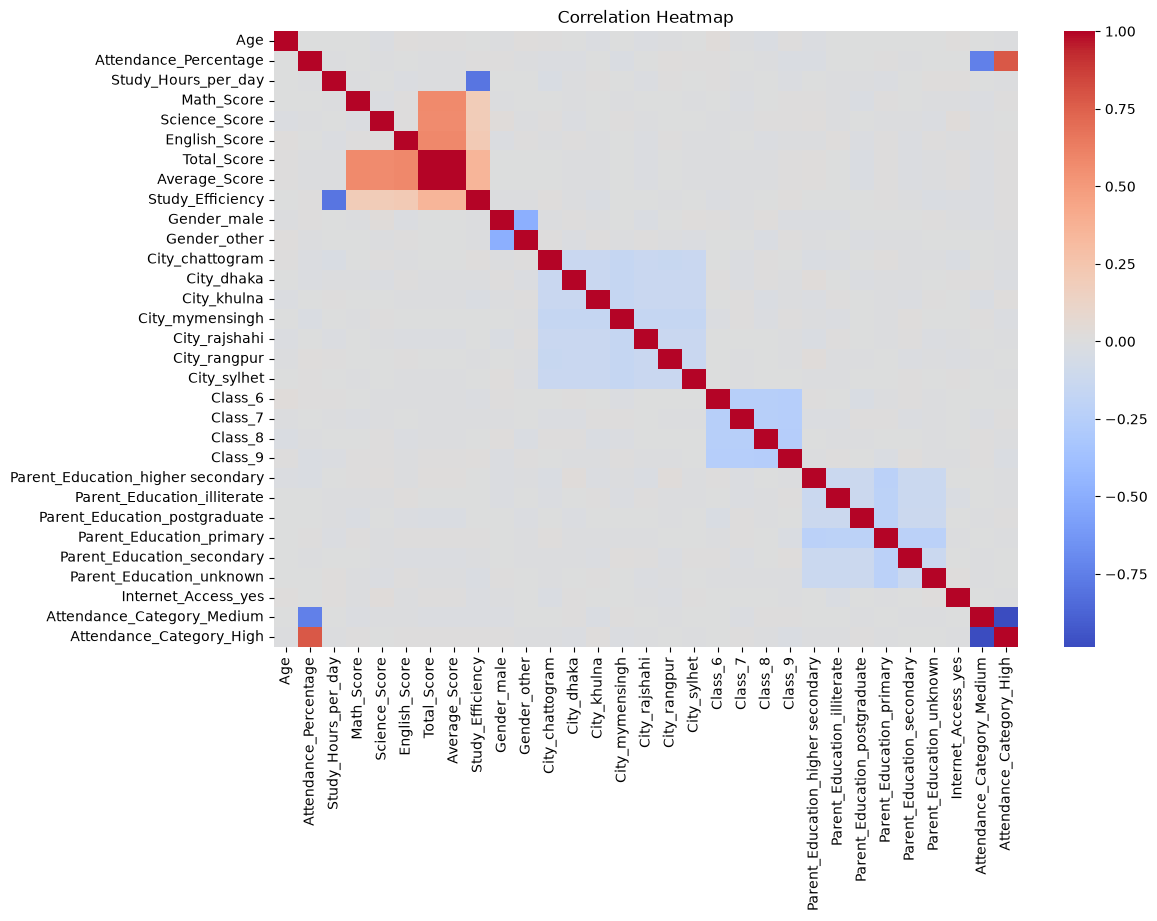

In [155]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

# Part C: Linear Regression

In this section, a Linear Regression model is built to predict the **Total_Score** of students. Since `Total_Score` is calculated directly from `Math_Score`, `Science_Score`, and `English_Score`, these three features are excluded from training to prevent data leakage and trivial prediction.

## Step 1: Prepare Features and Target

The target variable is **Total_Score**. The columns `Math_Score`, `Science_Score`, and `English_Score` are removed because the target is directly computed from them. Identifier columns such as `Student_ID` and `Name` are also excluded since they do not contribute to prediction.

In [156]:
# Prepare Features and Target
drop_cols = [
    'Student_ID',
    'Name',
    'Result',
    'Math_Score',
    'Science_Score',
    'English_Score',
    'Average_Score',
    'Study_Efficiency',
    'Total_Score'
]

X = df_encoded.drop(
    columns=drop_cols,
    errors='ignore'
)

y = df_encoded['Total_Score']

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

X.head()


Features Shape : (9850, 25)
Target Shape   : (9850,)


,Age,Attendance_Percentage,Study_Hours_per_day,Gender_male,Gender_other,City_chattogram,City_dhaka,City_khulna,City_mymensingh,City_rajshahi,City_rangpur,City_sylhet,Class_6,Class_7,Class_8,Class_9,Parent_Education_higher secondary,Parent_Education_illiterate,Parent_Education_postgraduate,Parent_Education_primary,Parent_Education_secondary,Parent_Education_unknown,Internet_Access_yes,Attendance_Category_Medium,Attendance_Category_High
0,0.636503,-0.814491,-0.361244,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0
1,-1.154799,0.600198,0.506746,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
2,-0.259148,-2.278387,0.362081,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0
3,-1.602624,-0.100996,0.796076,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
4,-0.259148,1.301392,-1.229235,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1


## Step 2: Train-Test Split

The dataset is divided into training (80%) and testing (20%) sets. The training data is used to train the model, while the testing data is used to evaluate its performance.

In [157]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(7880, 25)
(1970, 25)


## Step 3: Feature Scaling

Only the input features are standardized using StandardScaler. The scaler is fitted only on the training data to prevent data leakage, and then applied to both the training and testing sets.

In [158]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Step 4: Train Linear Regression Model

A Linear Regression model is trained using the scaled training data. The trained model is then used to predict the total scores of the test dataset.

In [159]:
lin_model = LinearRegression()

lin_model.fit(
    X_train_scaled,
    y_train
)

y_pred = lin_model.predict(
    X_test_scaled
)

print(y_test[:5])
print(y_pred[:5])
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

8920    191.0
9839    227.0
1851    180.0
6334    233.0
8516    221.0
Name: Total_Score, dtype: float64
[193.28213587 192.11958647 190.98194054 190.65607064 191.00038084]


,Actual,Predicted
0,191.0,193.282136
1,227.0,192.119586
2,180.0,190.981941
3,233.0,190.656071
4,221.0,191.000381
5,156.0,193.633078
6,232.0,193.649747
7,223.0,195.878389
8,203.0,192.753781
9,181.0,195.710896


## Step 5: Model Evaluation

The model is evaluated using R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

In [160]:
print("R² Score :", r2_score(y_test, y_pred))

print("MAE :", mean_absolute_error(
    y_test,
    y_pred
))

print("RMSE :", np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
))

R² Score : -0.00468050951325738
MAE : 27.946672339235693
RMSE : 34.72926017402623


In [161]:
print(X.columns.tolist())

['Age', 'Attendance_Percentage', 'Study_Hours_per_day', 'Gender_male', 'Gender_other', 'City_chattogram', 'City_dhaka', 'City_khulna', 'City_mymensingh', 'City_rajshahi', 'City_rangpur', 'City_sylhet', 'Class_6', 'Class_7', 'Class_8', 'Class_9', 'Parent_Education_higher secondary', 'Parent_Education_illiterate', 'Parent_Education_postgraduate', 'Parent_Education_primary', 'Parent_Education_secondary', 'Parent_Education_unknown', 'Internet_Access_yes', 'Attendance_Category_Medium', 'Attendance_Category_High']


In [162]:
print(df_encoded.columns.tolist())

['Student_ID', 'Name', 'Age', 'Attendance_Percentage', 'Study_Hours_per_day', 'Math_Score', 'Science_Score', 'English_Score', 'Total_Score', 'Result', 'Average_Score', 'Study_Efficiency', 'Gender_male', 'Gender_other', 'City_chattogram', 'City_dhaka', 'City_khulna', 'City_mymensingh', 'City_rajshahi', 'City_rangpur', 'City_sylhet', 'Class_6', 'Class_7', 'Class_8', 'Class_9', 'Parent_Education_higher secondary', 'Parent_Education_illiterate', 'Parent_Education_postgraduate', 'Parent_Education_primary', 'Parent_Education_secondary', 'Parent_Education_unknown', 'Internet_Access_yes', 'Attendance_Category_Medium', 'Attendance_Category_High']


## Step 6: Actual vs Predicted Values

A scatter plot is used to compare the actual total scores with the predicted scores. If the model performs well, most points should lie close to the diagonal reference line.

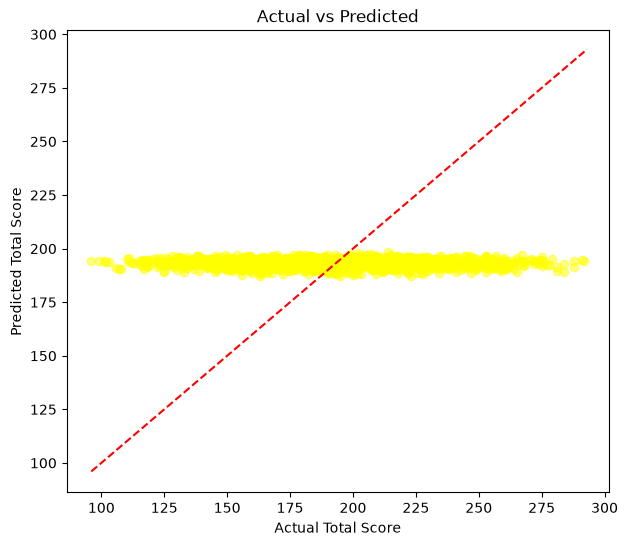

In [163]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color = 'yellow'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Total Score")

plt.ylabel("Predicted Total Score")

plt.title("Actual vs Predicted")

plt.show()

## Step 7: Coefficient Interpretation

The coefficients show how each feature influences the predicted total score. Positive coefficients indicate a positive relationship with the target, while negative coefficients indicate an inverse relationship.

In [164]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lin_model.coef_
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

coef_df

,Feature,Coefficient
24,Attendance_Category_High,1.734022
23,Attendance_Category_Medium,0.676669
4,Gender_other,0.621596
0,Age,0.520194
3,Gender_male,0.469947
19,Parent_Education_primary,0.434667
17,Parent_Education_illiterate,0.404780
15,Class_9,0.365265
16,Parent_Education_higher secondary,0.357439
22,Internet_Access_yes,0.353636


# Part D: Logistic Regression

In this section, a Logistic Regression model is developed to predict whether a student passes or fails. The target variable is converted into a binary format (Pass = 1, Fail = 0). A stratified train-test split is used to preserve the class distribution in both training and testing datasets. The model is evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC score, Confusion Matrix, and ROC Curve.

## Step 1: Prepare Features and Target

The target variable (`Result`) is converted into binary values where Pass = 1 and Fail = 0. Identifier columns are removed since they do not contribute to prediction.

In [165]:
# Binary Encoding
df_encoded['Result_binary'] = (
    df_copy['Result'] == 'pass'
).astype(int)

drop_cols = [
    'Student_ID',
    'Name',
    'Result',
    'Result_binary'
]

X = df_encoded.drop(
    columns=drop_cols,
    errors='ignore'
)

y = df_encoded['Result_binary']

print(X.shape)
print(y.shape)

(9850, 31)
(9850,)


## Step 2: Stratified Train-Test Split

The dataset is divided into training (80%) and testing (20%) sets using stratified sampling to preserve the original class distribution.

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Step 3: Feature Scaling

The scaler is fitted only on the training data to avoid data leakage. The same transformation is then applied to the testing data.

In [167]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Step 4: Train Logistic Regression

A Logistic Regression classifier is trained using the scaled training data.

In [168]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

y_pred = log_model.predict(
    X_test_scaled
)

y_prob = log_model.predict_proba(
    X_test_scaled
)[:,1]

## Step 5: Model Evaluation

The classification model is evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC score.

In [169]:
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC :", roc_auc_score(y_test,y_prob))

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy : 0.5583756345177665
Precision : 0.4418604651162791
Recall : 0.021965317919075144
F1 Score : 0.04185022026431718
ROC AUC : 0.5103496979049512

Classification Report

              precision    recall  f1-score   support

           0       0.56      0.98      0.71      1105
           1       0.44      0.02      0.04       865

    accuracy                           0.56      1970
   macro avg       0.50      0.50      0.38      1970
weighted avg       0.51      0.56      0.42      1970



## Step 6: Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified samples for both classes.

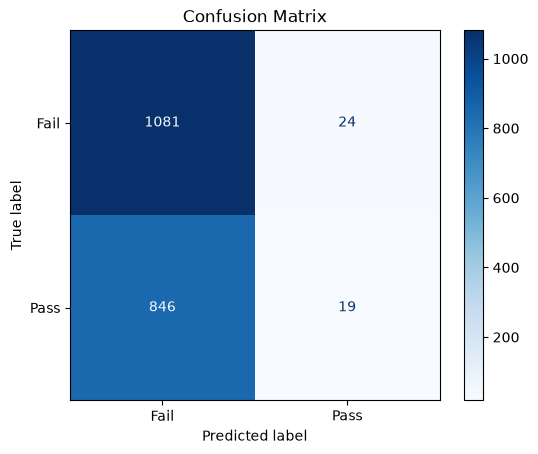

In [170]:
cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fail','Pass']
).plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

## Step 7: ROC Curve

The ROC curve illustrates the trade-off between the True Positive Rate and False Positive Rate across different classification thresholds.

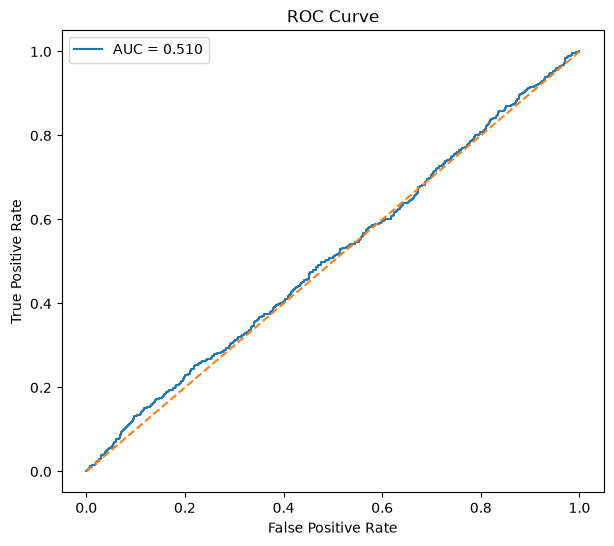

In [171]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}"

)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Step 8: Class Imbalance

The class distribution is checked to determine whether the dataset is balanced or imbalanced.

In [172]:
class_balance = (
    df_copy['Result']
    .value_counts(normalize=True)
    *100
)

print(class_balance)

Result
fail    56.081218
pass    43.918782
Name: proportion, dtype: float64


## Step 9: Coefficient Interpretation

Positive coefficients increase the probability of passing, while negative coefficients decrease the probability of passing.

In [173]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient
22,Parent_Education_higher secondary,0.057199
25,Parent_Education_primary,0.047080
23,Parent_Education_illiterate,0.045169
0,Age,0.042214
24,Parent_Education_postgraduate,0.034272
1,Attendance_Percentage,0.030755
26,Parent_Education_secondary,0.025638
3,Math_Score,0.017856
21,Class_9,0.015955
18,Class_6,0.015546


## Coefficient Interpretation

The logistic regression coefficients indicate how each feature affects the log-odds of a student passing the exam.

- **Parent_Education_higher secondary** has a positive coefficient (**0.057**), indicating that students whose parents have higher secondary education have slightly higher odds of passing compared to the reference category.

- **Attendance_Percentage** also has a positive coefficient (**0.031**), suggesting that students with higher attendance are more likely to pass the examination.

Overall, positive coefficients increase the probability (log-odds) of passing, while negative coefficients decrease it.

### Discussion

The target variable was converted into a binary format where Pass = 1 and Fail = 0. A stratified train-test split was used to preserve the class distribution in both datasets. Logistic Regression was trained on the scaled features and evaluated using multiple classification metrics. The confusion matrix and ROC curve were used to visualize the model performance, while the regression coefficients were analyzed to understand which features positively or negatively influenced the probability of passing.